# Modeling Identifikasi Suara Buka Tutup

In [41]:
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
import sounddevice as sd
import soundfile as sf
from IPython.display import Audio, display
import pickle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
data = pd.read_csv("../Preprocessing/data_preprocessed/features_buka_tutup.csv")

X = data.drop(columns=["file", "label"])
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Jumlah data latih: {len(X_train)}, data uji: {len(X_test)}")


Jumlah data latih: 320, data uji: 80


k=1 → Akurasi: 100.00%
k=3 → Akurasi: 100.00%
k=5 → Akurasi: 100.00%
k=7 → Akurasi: 100.00%
k=9 → Akurasi: 100.00%


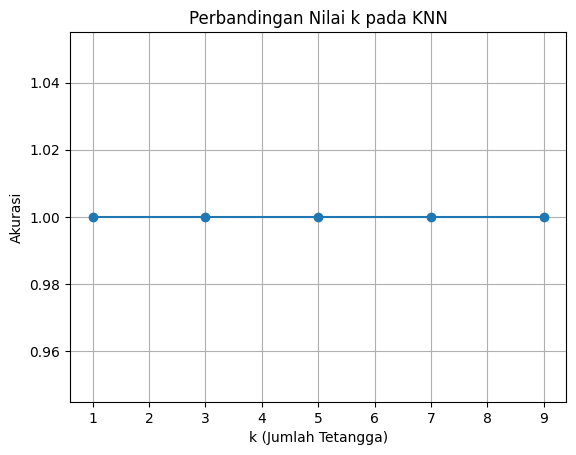

In [44]:
k_values = [1, 3, 5, 7, 9]
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"k={k} → Akurasi: {acc*100:.2f}%")

plt.plot(k_values, accuracies, marker='o')
plt.title("Perbandingan Nilai k pada KNN")
plt.xlabel("k (Jumlah Tetangga)")
plt.ylabel("Akurasi")
plt.grid(True)
plt.show()


Akurasi Model KNN (k=5): 100.00% 


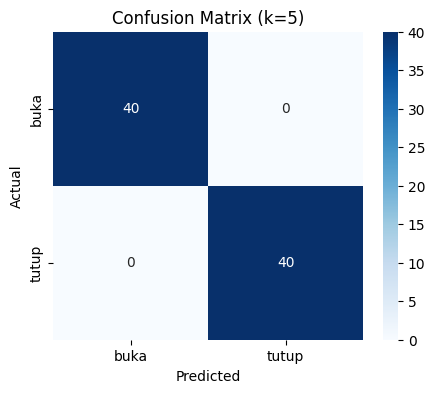

Classification Report:
              precision    recall  f1-score   support

        buka       1.00      1.00      1.00        40
       tutup       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [45]:
best_k = 5

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Akurasi Model KNN (k={best_k}): {acc*100:.2f}% ")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["buka", "tutup"])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["buka","tutup"], yticklabels=["buka","tutup"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (k={best_k})")
plt.show()

# Laporan detail (precision, recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["buka","tutup"]))


In [47]:
with open("model_knn_buka_tutup.pkl", "wb") as f:
    pickle.dump(knn_model, f)

with open("scaler_buka_tutup.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [50]:
print(" ")

model = pickle.load(open("model_knn_buka_tutup.pkl", "rb"))
scaler = pickle.load(open("scaler_buka_tutup.pkl", "rb"))

file_path = "../Preprocessing/data_preprocessed/val/tutup/tutup48k-tutup_151.wav.wav"   
sr = 16000

# load audio
y, _ = librosa.load(file_path, sr=sr)

display(Audio(data=y, rate=_))

# Preprocessing 
y_trimmed, _ = librosa.effects.trim(y, top_db=20)  
y_norm = y_trimmed / np.max(np.abs(y_trimmed))

# Ekstraksi fitur
def extract_features(y, sr):
    mean = np.mean(y)
    std = np.std(y)
    rms = np.mean(librosa.feature.rms(y=y))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return {
        "mean": mean,
        "std": std,
        "rms": rms,
        "zcr": zcr,
        "centroid": centroid,
        "bandwidth": bandwidth,
        "contrast": contrast,
        "rolloff": rolloff
    }

# Hitung fitur dari file audio
feat = extract_features(y_norm, sr)
feat_df = pd.DataFrame([feat])

# Normalisasi
feat_scaled = scaler.transform(feat_df)

pred = model.predict(feat_scaled)[0]
prob = model.predict_proba(feat_scaled)[0]
classes = model.classes_

# Hasil
print("Hasil Klasifikasi:", pred)
print("Probabilitas:")
for cls, p in zip(classes, prob):
    print(f"{cls}: {p*100:.2f}%")

Hasil Klasifikasi: tutup
Probabilitas:
buka: 0.00%
tutup: 100.00%


# Hasil Aplikasi

[Klik di sini untuk membuka aplikasi](https://deteksi-suara-buka-tutup.streamlit.app/)